In [4]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_style("whitegrid")

df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\shrey\AppData\Local\Temp\ipykernel_11792\2289209130.py:14: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")


In [5]:
los_no = df.loc[df["readmit_30"] == 0, "time_in_hospital"]
los_yes = df.loc[df["readmit_30"] == 1, "time_in_hospital"]


In [6]:
los_no.median(), los_yes.median()


(np.float64(4.0), np.float64(4.0))

In [7]:
u_los, p_los = mannwhitneyu(
    los_no,
    los_yes,
    alternative="two-sided"
)

u_los, p_los


(np.float64(465881132.0), np.float64(2.689648414149974e-59))

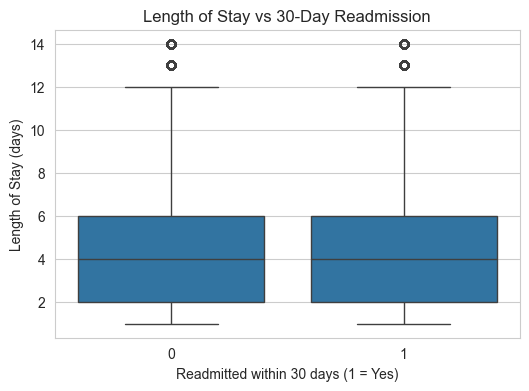

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="readmit_30", y="time_in_hospital")
plt.xlabel("Readmitted within 30 days (1 = Yes)")
plt.ylabel("Length of Stay (days)")
plt.title("Length of Stay vs 30-Day Readmission")
plt.show()


In [9]:
# create a primary diagnosis group from diag_1 if it doesn't exist, then show counts
if "primary_diagnosis_group" not in df.columns:
	def _map_diag(code):
		if pd.isna(code):
			return "Unknown"
		s = str(code)
		if s.startswith(("V", "E")):
			return "Other"
		digits = "".join(ch for ch in s if ch.isdigit())
		if len(digits) >= 3:
			prefix = int(digits[:3])
			if 390 <= prefix <= 459:
				return "Circulatory"
			if 460 <= prefix <= 519:
				return "Respiratory"
			if 520 <= prefix <= 579:
				return "Digestive"
			if prefix == 250:
				return "Diabetes"
			return "Other"
		return s

	df["primary_diagnosis_group"] = df["diag_1"].apply(_map_diag)

df["primary_diagnosis_group"].value_counts(dropna=False)


primary_diagnosis_group
Other          40391
Circulatory    30336
Respiratory    10407
Digestive       9208
Diabetes        8757
38              1688
8                515
79                86
53                55
70                46
9                 46
42                45
47                26
Unknown           21
3                 13
54                12
11                10
35                10
78                 9
88                 9
5                  9
41                 8
82                 7
34                 7
94                 7
66                 6
49                 5
31                 3
48                 2
7                  2
39                 2
27                 2
36                 2
52                 2
75                 2
58                 2
23                 2
57                 1
61                 1
98                 1
97                 1
84                 1
10                 1
Name: count, dtype: int64

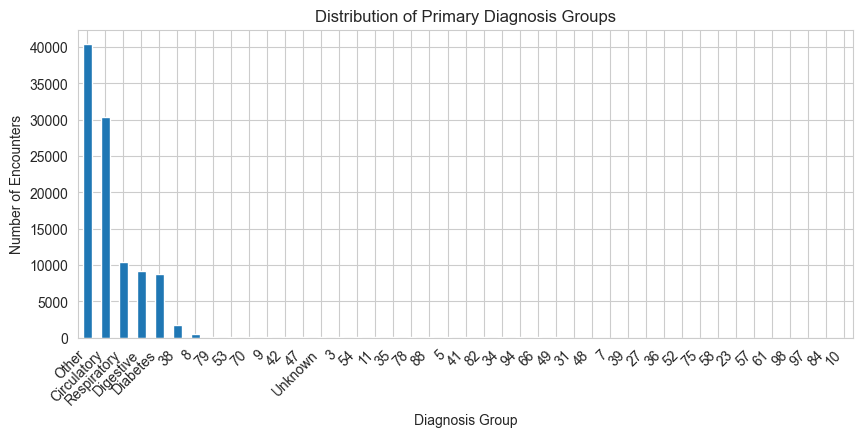

In [10]:
plt.figure(figsize=(10,4))
df["primary_diagnosis_group"].value_counts().plot(kind="bar")
plt.xlabel("Diagnosis Group")
plt.ylabel("Number of Encounters")
plt.title("Distribution of Primary Diagnosis Groups")
plt.xticks(rotation=45, ha="right")
plt.show()


In [11]:
diag_readmit_rate = (
    df.groupby("primary_diagnosis_group")["readmit_30"]
    .mean()
    .sort_values(ascending=False)
)

diag_readmit_rate



primary_diagnosis_group
23             0.500000
27             0.500000
48             0.500000
52             0.500000
82             0.428571
31             0.333333
34             0.285714
94             0.285714
Unknown        0.238095
8              0.137864
70             0.130435
Diabetes       0.129839
53             0.127273
Circulatory    0.114517
5              0.111111
42             0.111111
88             0.111111
38             0.110782
Other          0.107945
Respiratory    0.106851
Digestive      0.104909
79             0.093023
54             0.083333
47             0.076923
9              0.043478
10             0.000000
11             0.000000
39             0.000000
36             0.000000
35             0.000000
3              0.000000
57             0.000000
58             0.000000
41             0.000000
49             0.000000
75             0.000000
7              0.000000
66             0.000000
61             0.000000
84             0.000000
78             0

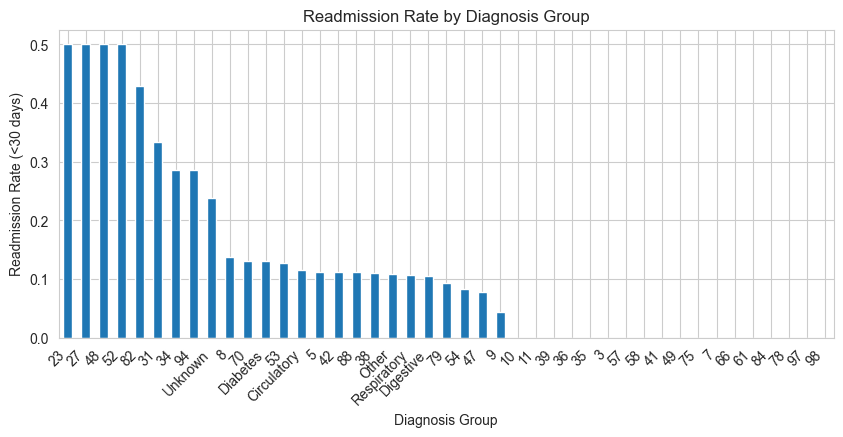

In [12]:
plt.figure(figsize=(10,4))
diag_readmit_rate.plot(kind="bar")
plt.ylabel("Readmission Rate (<30 days)")
plt.xlabel("Diagnosis Group")
plt.title("Readmission Rate by Diagnosis Group")
plt.xticks(rotation=45, ha="right")
plt.show()


In [13]:
high_risk_diags = diag_readmit_rate.head(3).index.tolist()
high_risk_diags


['23', '27', '48']

In [14]:
df_high = df[df["primary_diagnosis_group"].isin(high_risk_diags)]


In [15]:
df_high.groupby(
    ["primary_diagnosis_group", "readmit_30"]
)["number_inpatient"].median()


primary_diagnosis_group  readmit_30
23                       0             3.0
                         1             2.0
27                       0             0.0
                         1             3.0
48                       0             0.0
                         1             0.0
Name: number_inpatient, dtype: float64

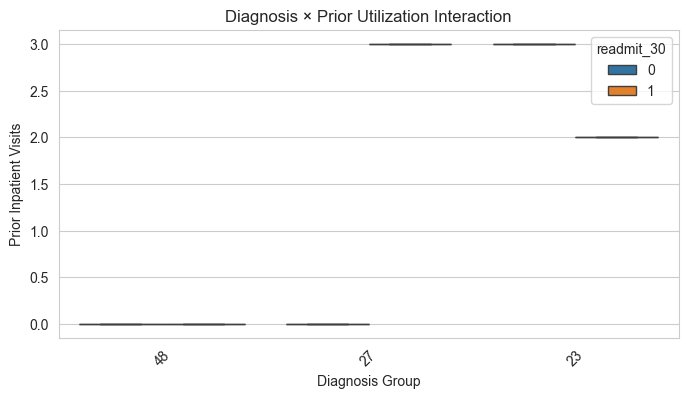

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df_high,
    x="primary_diagnosis_group",
    y="number_inpatient",
    hue="readmit_30"
)
plt.xlabel("Diagnosis Group")
plt.ylabel("Prior Inpatient Visits")
plt.title("Diagnosis × Prior Utilization Interaction")
plt.xticks(rotation=45)
plt.show()


In [17]:
numeric_vars = [
    "number_inpatient",
    "num_medications",
    "num_lab_procedures",
    "time_in_hospital"
]

separation_results = []

for col in numeric_vars:
    med_0 = df.loc[df["readmit_30"] == 0, col].median()
    med_1 = df.loc[df["readmit_30"] == 1, col].median()
    
    separation_results.append({
        "variable": col,
        "median_non_readmit": med_0,
        "median_readmit": med_1,
        "absolute_median_diff": abs(med_1 - med_0)
    })

separation_df = pd.DataFrame(separation_results)
separation_df.sort_values("absolute_median_diff", ascending=False)


,variable,median_non_readmit,median_readmit,absolute_median_diff
1,num_medications,15.0,16.0,1.0
2,num_lab_procedures,44.0,45.0,1.0
0,number_inpatient,0.0,0.0,0.0
3,time_in_hospital,4.0,4.0,0.0


In [18]:
corr_matrix = df[numeric_vars].corr()
corr_matrix


,number_inpatient,num_medications,num_lab_procedures,time_in_hospital
number_inpatient,1.000000,0.064194,0.039231,0.073623
num_medications,0.064194,1.000000,0.268161,0.466135
num_lab_procedures,0.039231,0.268161,1.000000,0.318450
time_in_hospital,0.073623,0.466135,0.318450,1.000000


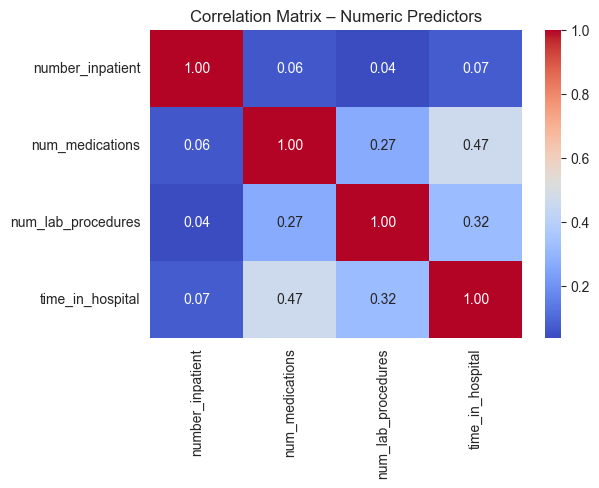

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix – Numeric Predictors")
plt.show()


In [20]:
age_readmit_rate = (
    df.groupby("age")["readmit_30"]
    .mean()
    .sort_index()
)

age_readmit_rate


age
[0-10)      0.018634
[10-20)     0.057887
[20-30)     0.142426
[30-40)     0.112318
[40-50)     0.106040
[50-60)     0.096662
[60-70)     0.111284
[70-80)     0.117731
[80-90)     0.120835
[90-100)    0.110992
Name: readmit_30, dtype: float64

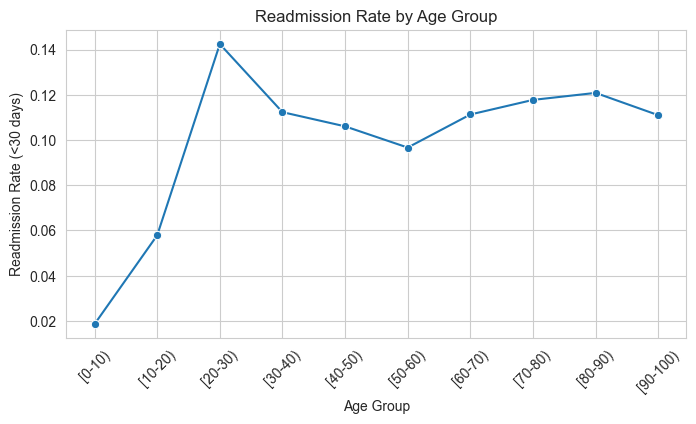

In [21]:
plt.figure(figsize=(8,4))
sns.lineplot(
    x=age_readmit_rate.index,
    y=age_readmit_rate.values,
    marker="o"
)
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (<30 days)")
plt.title("Readmission Rate by Age Group")
plt.xticks(rotation=45)
plt.show()


In [22]:
age_utilization = (
    df.groupby("age")
    .agg(
        mean_inpatient=("number_inpatient", "mean"),
        readmission_rate=("readmit_30", "mean")
    )
)

age_utilization


,mean_inpatient,readmission_rate
age,,
[0-10),0.080745,0.018634
[10-20),0.532562,0.057887
[20-30),1.338564,0.142426
[30-40),0.762649,0.112318
[40-50),0.724109,0.106040
[50-60),0.615090,0.096662
[60-70),0.606147,0.111284
[70-80),0.610365,0.117731
[80-90),0.609118,0.120835


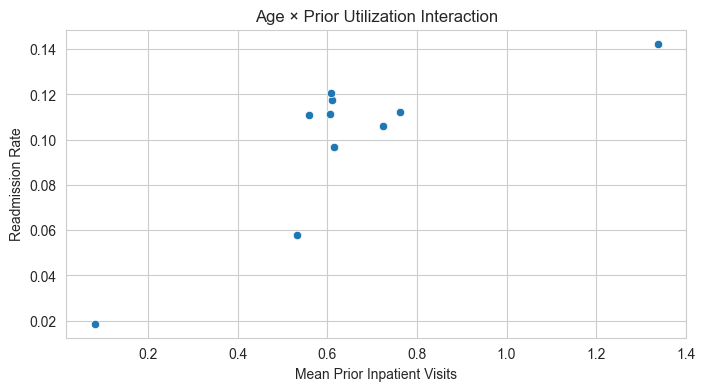

In [23]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=age_utilization,
    x="mean_inpatient",
    y="readmission_rate"
)
plt.xlabel("Mean Prior Inpatient Visits")
plt.ylabel("Readmission Rate")
plt.title("Age × Prior Utilization Interaction")
plt.show()


In [24]:
df.groupby(
    ["age", "readmit_30"]
)["time_in_hospital"].median()


age       readmit_30
[0-10)    0             2.0
          1             3.0
[10-20)   0             2.0
          1             3.0
[20-30)   0             3.0
          1             3.0
[30-40)   0             3.0
          1             3.0
[40-50)   0             3.0
          1             4.0
[50-60)   0             3.0
          1             4.0
[60-70)   0             4.0
          1             4.0
[70-80)   0             4.0
          1             4.0
[80-90)   0             4.0
          1             4.0
[90-100)  0             4.0
          1             4.0
Name: time_in_hospital, dtype: float64

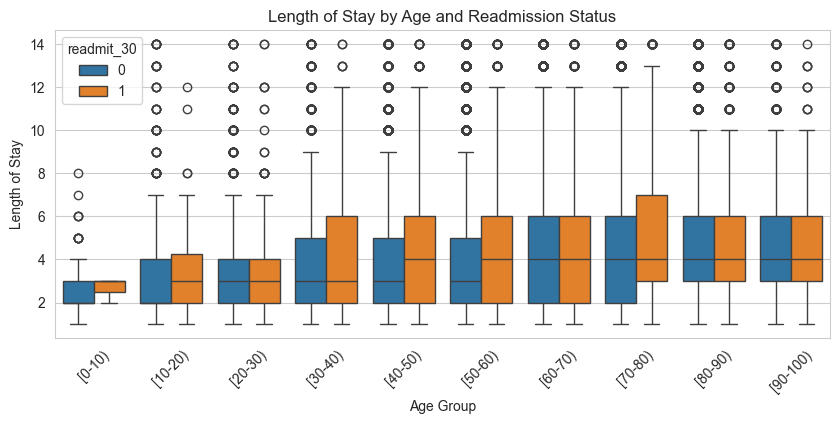

In [25]:
plt.figure(figsize=(10,4))
sns.boxplot(
    data=df,
    x="age",
    y="time_in_hospital",
    hue="readmit_30"
)
plt.xlabel("Age Group")
plt.ylabel("Length of Stay")
plt.title("Length of Stay by Age and Readmission Status")
plt.xticks(rotation=45)
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")


C:\Users\shrey\AppData\Local\Temp\ipykernel_11792\3640708910.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")


In [27]:
medication_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]


In [28]:
sparsity_summary = []

for col in medication_cols:
    no_pct = (df[col] == "No").mean() * 100
    yes_pct = 100 - no_pct
    
    sparsity_summary.append({
        "medication": col,
        "percent_no": round(no_pct, 2),
        "percent_prescribed": round(yes_pct, 2)
    })

sparsity_df = (
    pd.DataFrame(sparsity_summary)
    .sort_values("percent_prescribed", ascending=False)
)

sparsity_df


,medication,percent_no,percent_prescribed
17,insulin,46.56,53.44
0,metformin,80.36,19.64
6,glipizide,87.53,12.47
7,glyburide,89.53,10.47
9,pioglitazone,92.80,7.20
10,rosiglitazone,93.75,6.25
4,glimepiride,94.90,5.10
1,repaglinide,98.49,1.51
18,glyburide-metformin,99.31,0.69
2,nateglinide,99.31,0.69


In [29]:
med_presence_results = []

for col in medication_cols:
    prescribed = df[col] != "No"
    
    readmit_rate_prescribed = df.loc[prescribed, "readmit_30"].mean()
    readmit_rate_not = df.loc[~prescribed, "readmit_30"].mean()
    
    med_presence_results.append({
        "medication": col,
        "readmit_rate_prescribed": readmit_rate_prescribed,
        "readmit_rate_not_prescribed": readmit_rate_not,
        "difference": readmit_rate_prescribed - readmit_rate_not
    })

med_presence_df = (
    pd.DataFrame(med_presence_results)
    .sort_values("difference", ascending=False)
)

med_presence_df


,medication,readmit_rate_prescribed,readmit_rate_not_prescribed,difference
1,repaglinide,0.133203,0.111267,0.021936
17,insulin,0.121380,0.100374,0.021006
6,glipizide,0.114457,0.111192,0.003265
2,nateglinide,0.113798,0.111584,0.002214
18,glyburide-metformin,0.110482,0.111607,-0.001125
7,glyburide,0.106291,0.112220,-0.005929
12,miglitol,0.105263,0.111602,-0.006338
9,pioglitazone,0.105622,0.112063,-0.006441
10,rosiglitazone,0.104478,0.112074,-0.007597
4,glimepiride,0.102100,0.112110,-0.010010


In [30]:
df["on_insulin_tmp"] = df["insulin"] != "No"


In [31]:
df.groupby("on_insulin_tmp")["readmit_30"].mean()


on_insulin_tmp
False    0.100374
True     0.121380
Name: readmit_30, dtype: float64

In [32]:
df.groupby("on_insulin_tmp")[
    ["number_inpatient", "num_medications"]
].median()


,number_inpatient,num_medications
on_insulin_tmp,,
False,0.0,13.0
True,0.0,16.0


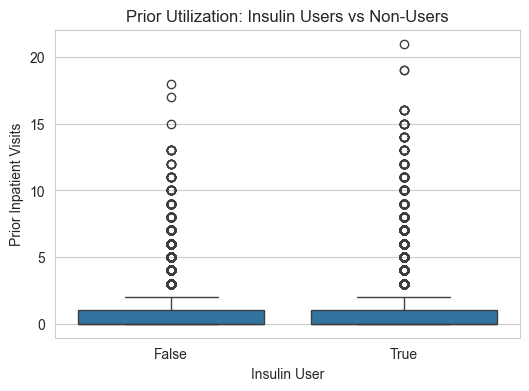

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="on_insulin_tmp", y="number_inpatient")
plt.xlabel("Insulin User")
plt.ylabel("Prior Inpatient Visits")
plt.title("Prior Utilization: Insulin Users vs Non-Users")
plt.show()


In [34]:
df["med_change_tmp"] = df["change"] == "Ch"


In [35]:
df.groupby("med_change_tmp")["readmit_30"].mean()


med_change_tmp
False    0.105908
True     0.118228
Name: readmit_30, dtype: float64

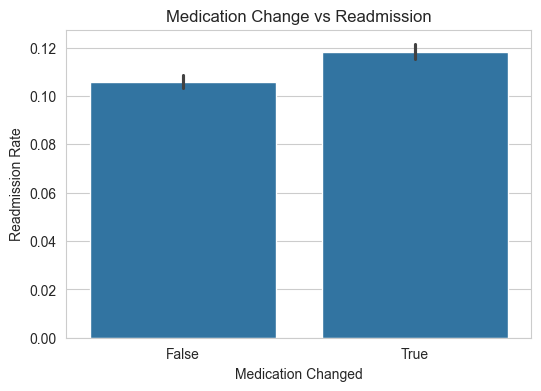

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=df["med_change_tmp"],
    y=df["readmit_30"]
)
plt.xlabel("Medication Changed")
plt.ylabel("Readmission Rate")
plt.title("Medication Change vs Readmission")
plt.show()


In [37]:
df.groupby("diabetesMed")["readmit_30"].mean()


diabetesMed
No     0.095971
Yes    0.116267
Name: readmit_30, dtype: float64

In [38]:
df.groupby("diabetesMed")[
    ["number_inpatient", "num_medications"]
].median()



,number_inpatient,num_medications
diabetesMed,,
No,0.0,12.0
Yes,0.0,15.0


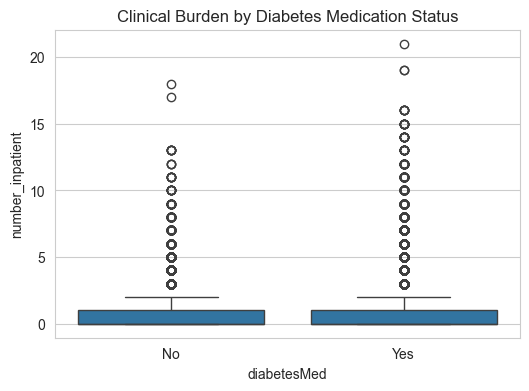

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="diabetesMed", y="number_inpatient")
plt.title("Clinical Burden by Diabetes Medication Status")
plt.show()


In [40]:
combo_cols = [
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

combo_freq = {}

for col in combo_cols:
    combo_freq[col] = (df[col] != "No").mean() * 100

pd.Series(combo_freq).sort_values(ascending=False)


glyburide-metformin         0.693748
glipizide-metformin         0.012774
metformin-rosiglitazone     0.001965
glimepiride-pioglitazone    0.000983
metformin-pioglitazone      0.000983
dtype: float64

In [41]:
df["medication_burden_tmp"] = (
    df[medication_cols] != "No"
).sum(axis=1)


In [42]:
df["medication_burden_tmp"].value_counts().sort_index()


medication_burden_tmp
0    23403
1    47314
2    21873
3     7778
4     1335
5       58
6        5
Name: count, dtype: int64

In [43]:
df["medication_burden_tmp"].value_counts().sort_index()


medication_burden_tmp
0    23403
1    47314
2    21873
3     7778
4     1335
5       58
6        5
Name: count, dtype: int64

In [44]:
df.groupby("medication_burden_tmp")["readmit_30"].mean()


medication_burden_tmp
0    0.095971
1    0.122923
2    0.107210
3    0.104397
4    0.101873
5    0.000000
6    0.400000
Name: readmit_30, dtype: float64

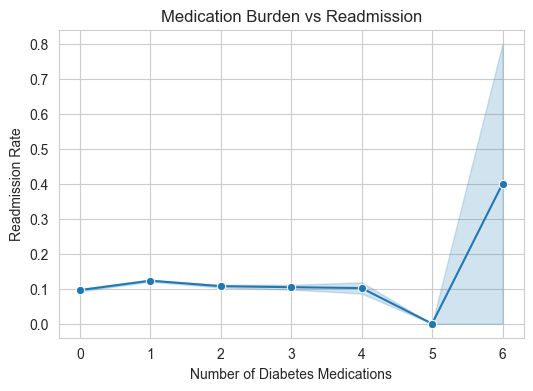

In [45]:
plt.figure(figsize=(6,4))
sns.lineplot(
    data=df,
    x="medication_burden_tmp",
    y="readmit_30",
    marker="o"
)
plt.xlabel("Number of Diabetes Medications")
plt.ylabel("Readmission Rate")
plt.title("Medication Burden vs Readmission")
plt.show()


In [46]:
df.groupby("on_insulin_tmp")["number_inpatient"].median()


on_insulin_tmp
False    0.0
True     0.0
Name: number_inpatient, dtype: float64

In [47]:
df.groupby("med_change_tmp")["number_inpatient"].median()


med_change_tmp
False    0.0
True     0.0
Name: number_inpatient, dtype: float64

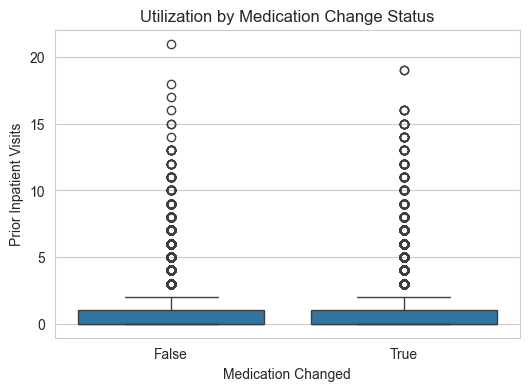

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x="med_change_tmp",
    y="number_inpatient"
)
plt.xlabel("Medication Changed")
plt.ylabel("Prior Inpatient Visits")
plt.title("Utilization by Medication Change Status")
plt.show()


In [49]:
df.drop(
    columns=[
        "on_insulin_tmp",
        "med_change_tmp",
        "medication_burden_tmp"
    ],
    inplace=True
)



In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")

print("Shape:", df.shape)
df.head()



C:\Users\shrey\AppData\Local\Temp\ipykernel_11792\96589130.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\internship\\datasets\\processed\\diabetic_data_base_table_mapped.csv")


Shape: (101766, 51)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmit_30
0,2278392,8222157,Caucasian,Female,[0-10),NaN,NaN,Not Mapped,Physician Referral,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,Emergency,Discharged to home,Emergency Room,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,Emergency,Discharged to home,Emergency Room,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,Emergency,Discharged to home,Emergency Room,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,Emergency,Discharged to home,Emergency Room,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [51]:
# Count encounters per patient
patient_counts = df.groupby("patient_nbr")["encounter_id"].count()

# Patients with more than 1 encounter
multi_patients = patient_counts[patient_counts > 1].index

df_multi = df[df["patient_nbr"].isin(multi_patients)].copy()

print("Total unique patients:", df["patient_nbr"].nunique())
print("Patients with multiple encounters:", len(multi_patients))
print("Total rows for multi-encounter patients:", df_multi.shape[0])


Total unique patients: 71518
Patients with multiple encounters: 16773
Total rows for multi-encounter patients: 47021


In [52]:
df_multi = df_multi.sort_values(["patient_nbr", "encounter_id"])


In [53]:
patient_readmission_summary = df_multi.groupby("patient_nbr").agg(
    total_encounters=("encounter_id", "count"),
    readmit_30_sum=("readmit_30", "sum"),
    readmitted_binary_sum=("readmitted", lambda x: (x != "NO").sum())
).reset_index()

patient_readmission_summary["ever_readmit_30"] = \
    (patient_readmission_summary["readmit_30_sum"] > 0).astype(int)

patient_readmission_summary.head()


,patient_nbr,total_encounters,readmit_30_sum,readmitted_binary_sum,ever_readmit_30
0,135,2,1,2,1
1,1152,5,0,4,0
2,1314,3,1,2,1
3,5220,4,0,3,0
4,5337,2,0,1,0


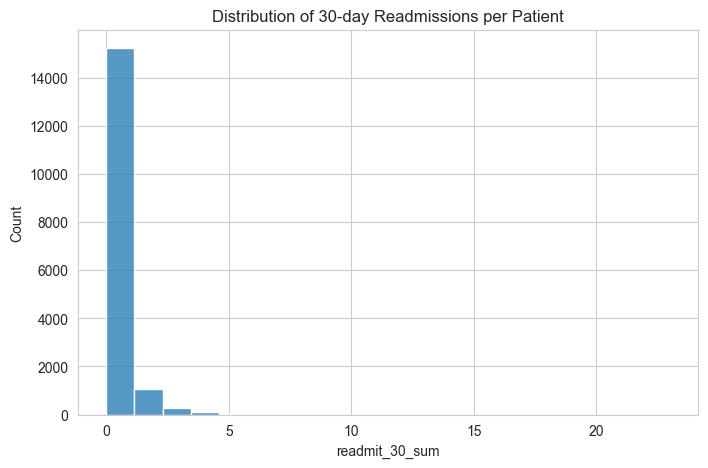

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(patient_readmission_summary["readmit_30_sum"], bins=20)
plt.title("Distribution of 30-day Readmissions per Patient")
plt.show()



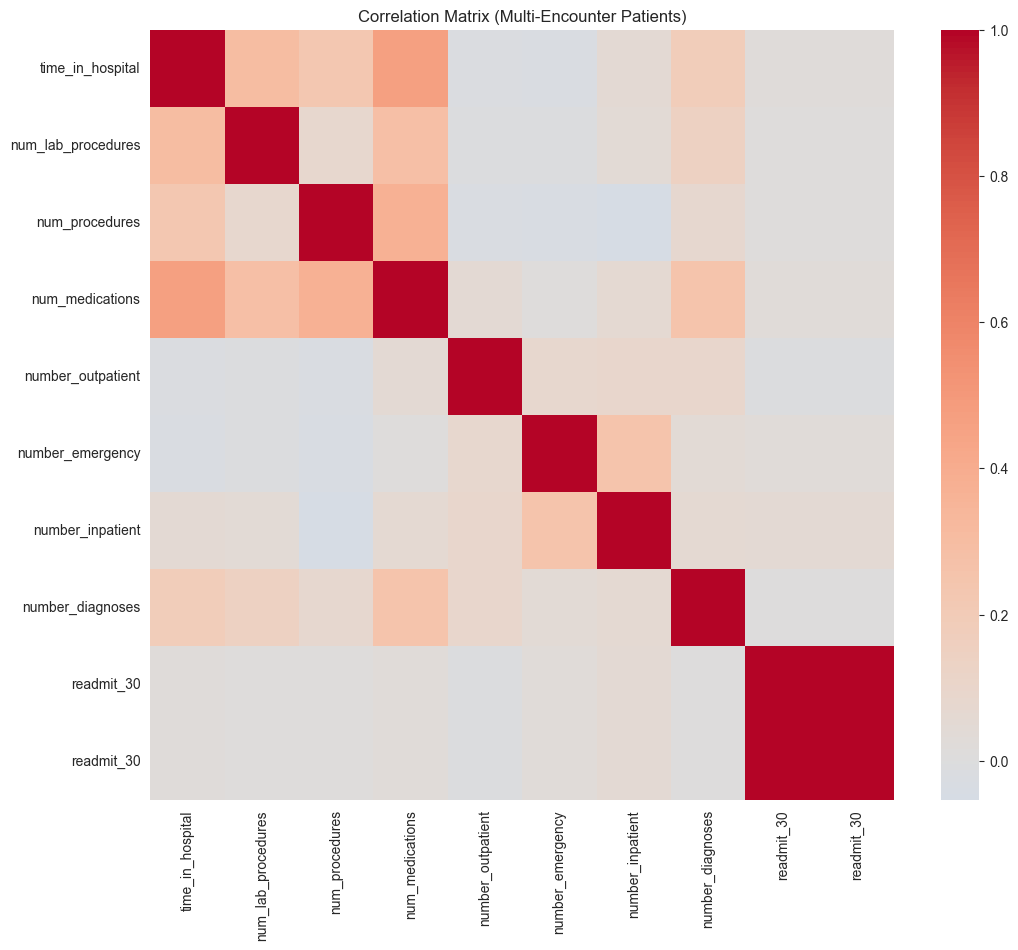

In [55]:
numeric_cols = df_multi.select_dtypes(include=np.number).columns.tolist()

# Remove IDs
numeric_cols = [col for col in numeric_cols 
                if col not in ["encounter_id", "patient_nbr"]]

corr_matrix = df_multi[numeric_cols + ["readmit_30"]].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Multi-Encounter Patients)")
plt.show()


In [56]:
patient_features = df_multi.groupby("patient_nbr").agg(
    total_encounters=("encounter_id", "count"),
    avg_time_in_hospital=("time_in_hospital", "mean"),
    total_lab_procedures=("num_lab_procedures", "sum"),
    total_medications=("num_medications", "sum"),
    avg_medications=("num_medications", "mean"),
    total_inpatient_visits=("number_inpatient", "sum"),
    total_emergency_visits=("number_emergency", "sum"),
    total_outpatient_visits=("number_outpatient", "sum"),
    readmit_30_sum=("readmit_30", "sum")
).reset_index()

patient_features["high_readmit_flag"] = \
    (patient_features["readmit_30_sum"] > 0).astype(int)

patient_features.head()


,patient_nbr,total_encounters,avg_time_in_hospital,total_lab_procedures,total_medications,avg_medications,total_inpatient_visits,total_emergency_visits,total_outpatient_visits,readmit_30_sum,high_readmit_flag
0,135,2,5.5,108,47,23.5,1,0,0,1,1
1,1152,5,8.4,209,81,16.2,7,0,0,0,0
2,1314,3,2.0,151,39,13.0,3,0,0,1,1
3,5220,4,5.5,165,60,15.0,5,0,0,0,0
4,5337,2,5.5,71,28,14.0,1,0,0,0,0


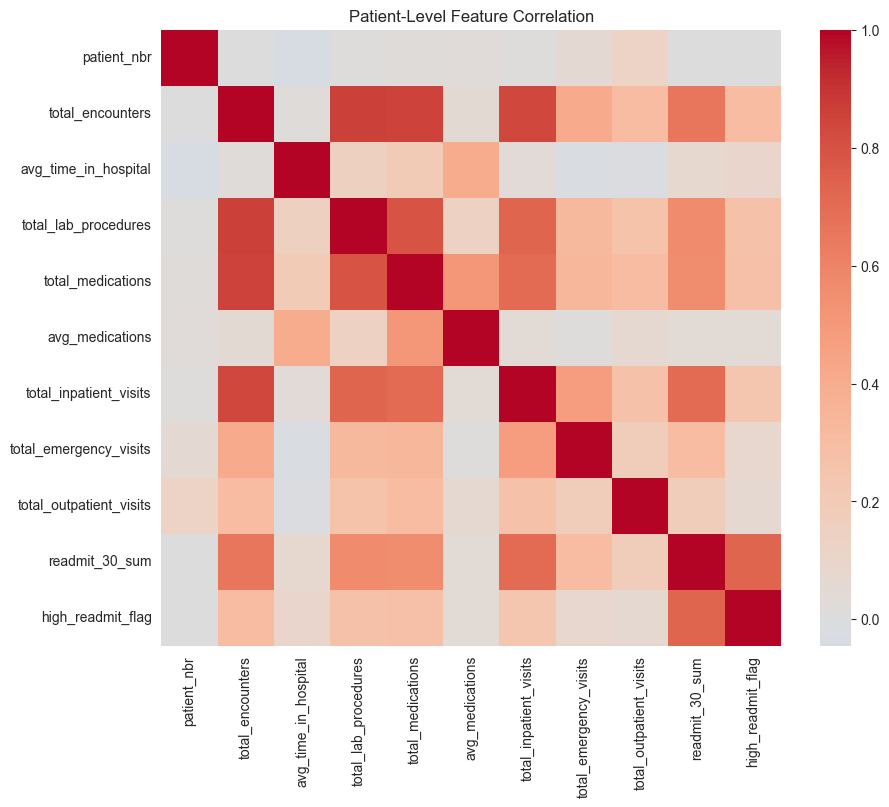

In [57]:
corr_patient = patient_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_patient, cmap="coolwarm", center=0)
plt.title("Patient-Level Feature Correlation")
plt.show()


In [58]:
readmit_group = patient_features.groupby("high_readmit_flag").mean()

readmit_group


,patient_nbr,total_encounters,avg_time_in_hospital,total_lab_procedures,total_medications,avg_medications,total_inpatient_visits,total_emergency_visits,total_outpatient_visits,readmit_30_sum
high_readmit_flag,,,,,,,,,,
0,5.220889e+07,2.397031,4.401209,102.082335,38.733102,16.073026,1.691341,0.535280,1.134488,0.000000
1,5.271205e+07,3.419166,4.840661,146.849580,57.507049,16.643351,5.726905,1.464907,1.727055,1.378374


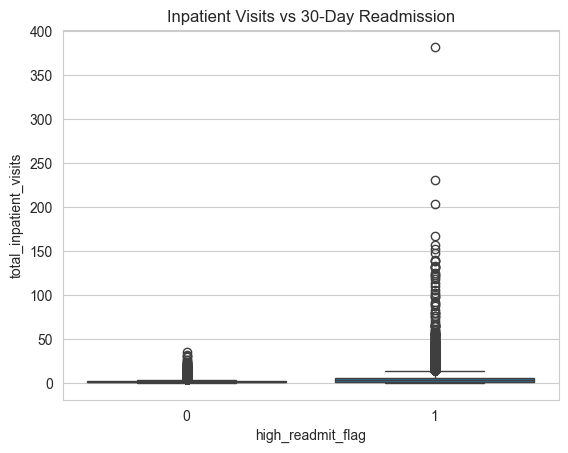

In [59]:
sns.boxplot(
    x="high_readmit_flag",
    y="total_inpatient_visits",
    data=patient_features
)
plt.title("Inpatient Visits vs 30-Day Readmission")
plt.show()


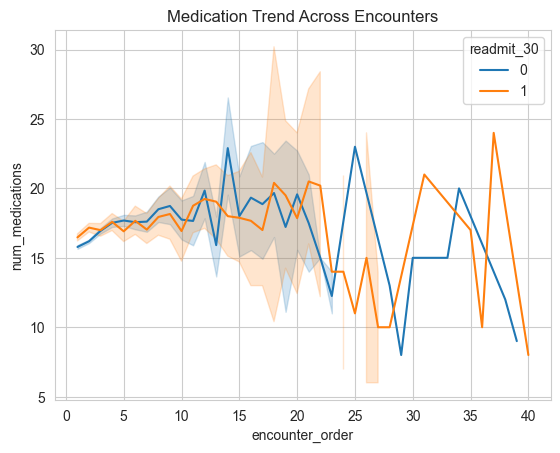

In [60]:
df_multi["encounter_order"] = \
    df_multi.groupby("patient_nbr").cumcount() + 1

sns.lineplot(
    data=df_multi,
    x="encounter_order",
    y="num_medications",
    hue="readmit_30",
    estimator="mean"
)

plt.title("Medication Trend Across Encounters")
plt.show()
